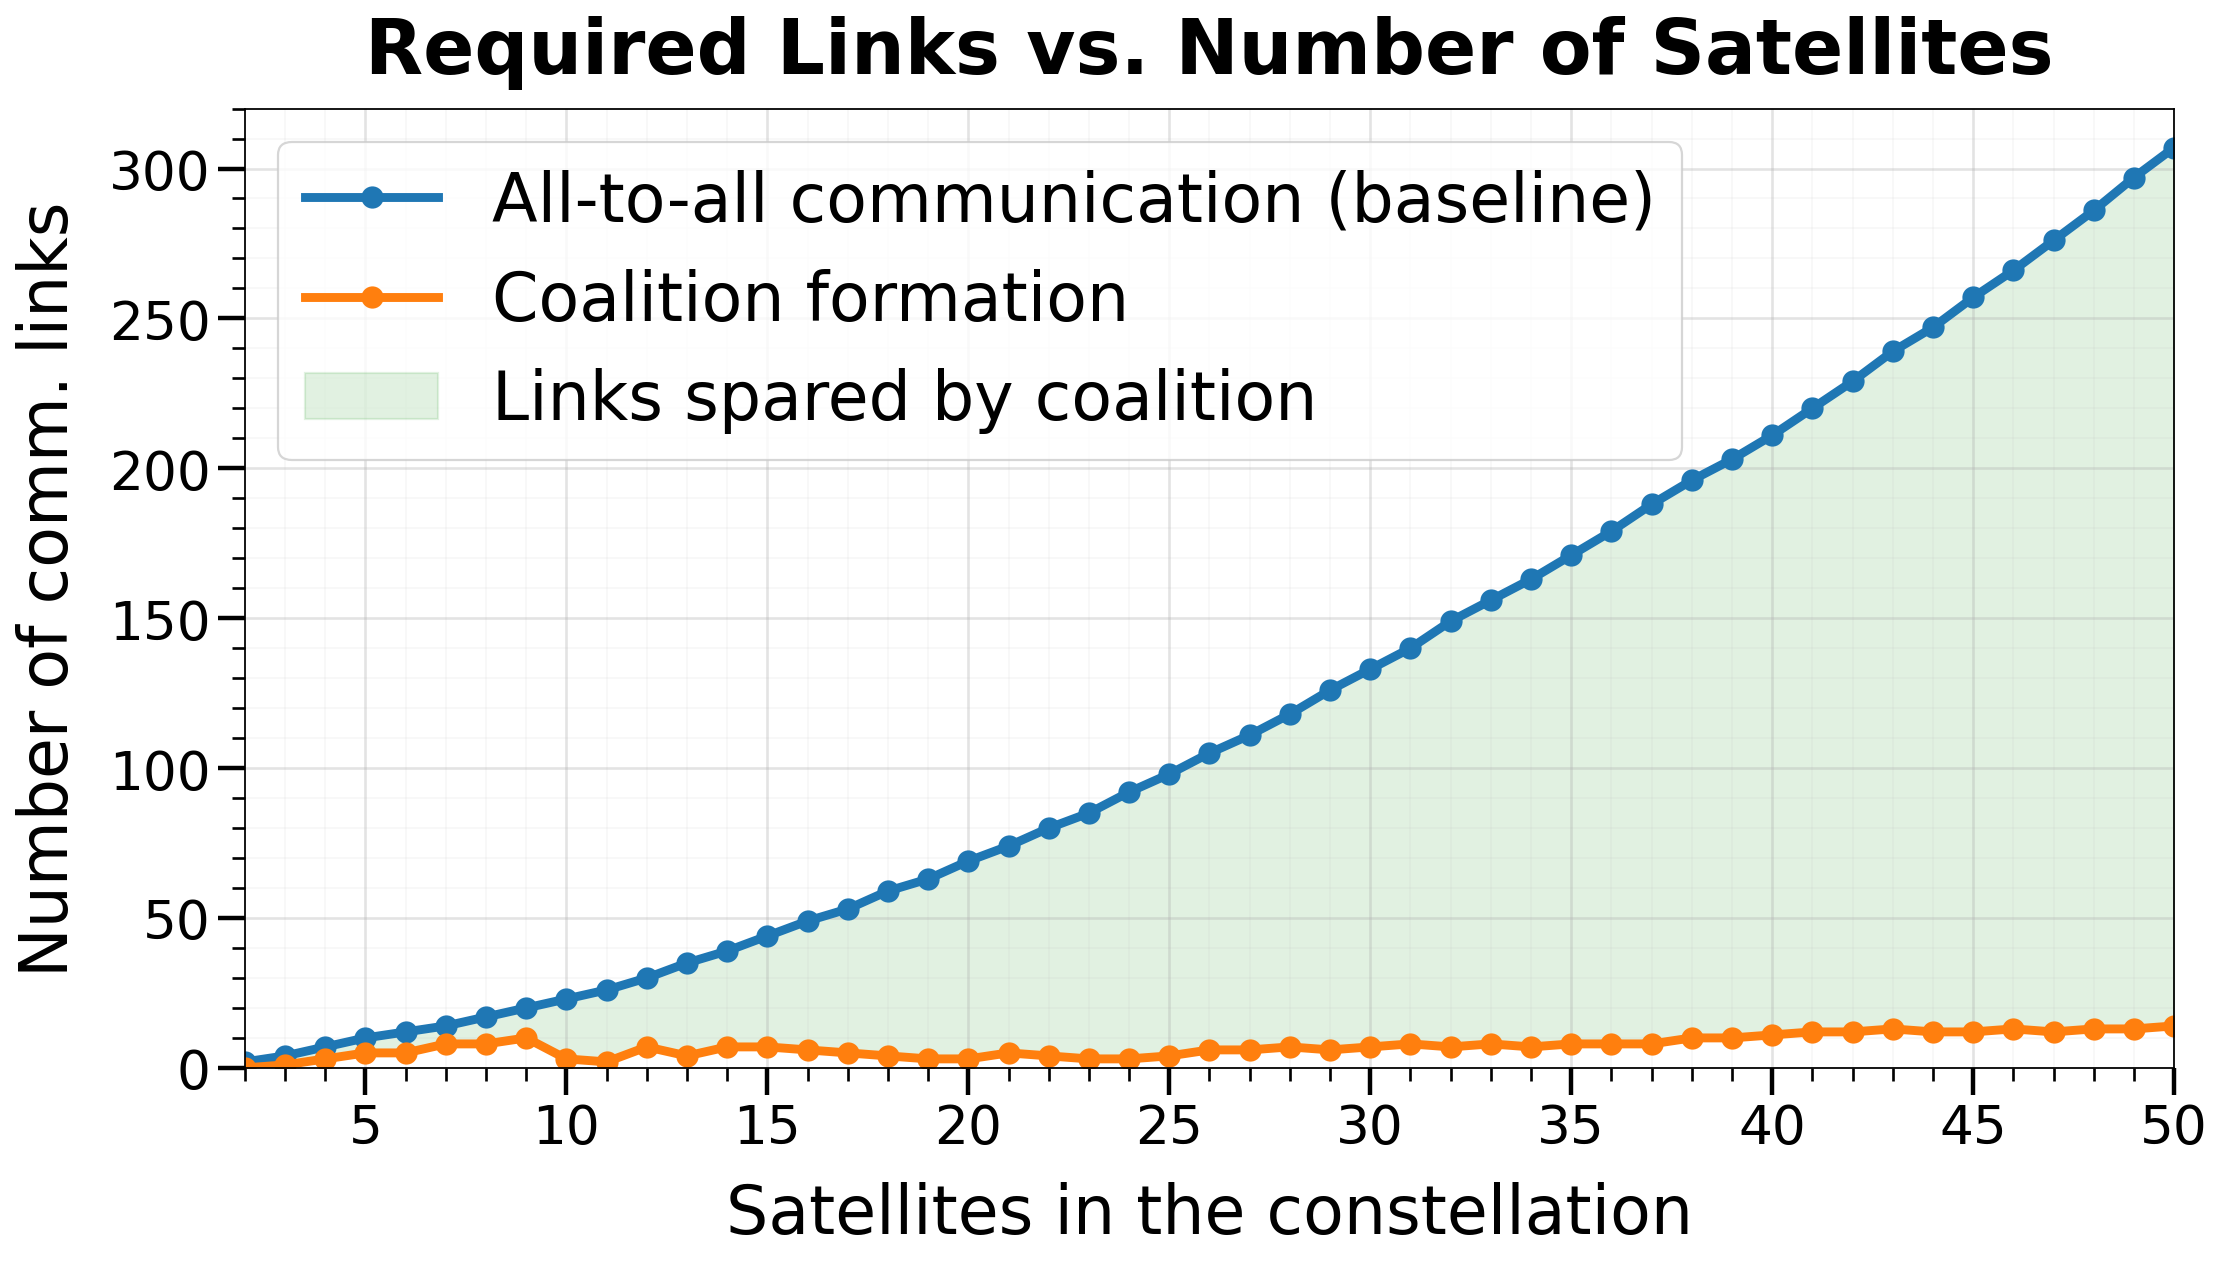

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, StrMethodFormatter

# Reproducible synthetic data shaped to match the reference figure.
rng = np.random.default_rng(42)
satellites = np.arange(2, 51)

raw_increments = np.linspace(2.2, 9.5, satellites.size) + rng.normal(0, 0.8, satellites.size)
increments = np.clip(np.round(raw_increments), 1, None).astype(int)
total_edges = np.cumsum(increments)

# Rescale so the last point lands near ~307 like the reference.
total_edges = np.round(total_edges * (307 / total_edges[-1])).astype(int)
for i in range(1, total_edges.size):
    if total_edges[i] <= total_edges[i - 1]:
        total_edges[i] = total_edges[i - 1] + 1

# Coalition edges: low values with small fluctuations and slight growth.
after_coalition = np.round(0.05 * total_edges + rng.normal(0, 1.2, satellites.size)).astype(int)

early = satellites <= 9
after_coalition[early] = np.clip(
    np.round(np.linspace(0, 10, early.sum()) + rng.normal(0, 0.7, early.sum())),
    0,
    None,
).astype(int)

mid = (satellites >= 10) & (satellites <= 18)
after_coalition[mid] += np.round(
    5 * np.sin(np.linspace(0, np.pi, mid.sum())) + rng.normal(0, 0.5, mid.sum())
).astype(int)

after_coalition = np.clip(after_coalition, 0, 20)
links_spared = total_edges - after_coalition

# Slide-friendly styling with clearer domain language and larger visual elements.
fig, ax = plt.subplots(figsize=(14, 8), dpi=160)

ax.plot(
    satellites,
    total_edges,
    marker="o",
    markersize=9,
    linewidth=4,
    label="All-to-all communication (baseline)",
)
ax.plot(
    satellites,
    after_coalition,
    marker="o",
    markersize=9,
    linewidth=4,
    label="Coalition formation",
)
ax.fill_between(
    satellites,
    after_coalition,
    total_edges,
    color="tab:green",
    alpha=0.14,
    label="Links spared by coalition",
)

ax.set_title("Required Links vs. Number of Satellites", fontsize=34, fontweight="bold", pad=16)
ax.set_xlabel("Satellites in the constellation", fontsize=30, labelpad=12)
ax.set_ylabel("Number of comm. links", fontsize=30, labelpad=12)

ax.set_xlim(2, 50)
ax.set_ylim(0, 320)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(50))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.tick_params(axis="both", which="major", labelsize=24, length=12, width=2)
ax.tick_params(axis="both", which="minor", length=6, width=1.2)
ax.grid(which="major", alpha=0.35, linewidth=1.2)
ax.grid(which="minor", alpha=0.1, linewidth=0.7)

final_saved = int(links_spared[-1])
final_saved_pct = 100 * final_saved / total_edges[-1]
""" ax.text(
    0.98,
    0.05,
    f"At 50 satellites: {final_saved} links spared ({final_saved_pct:.1f}%)",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=30,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.8, "edgecolor": "0.7"},
) """

ax.legend(loc="upper left", fontsize=30, frameon=True)
plt.tight_layout()
plt.show()

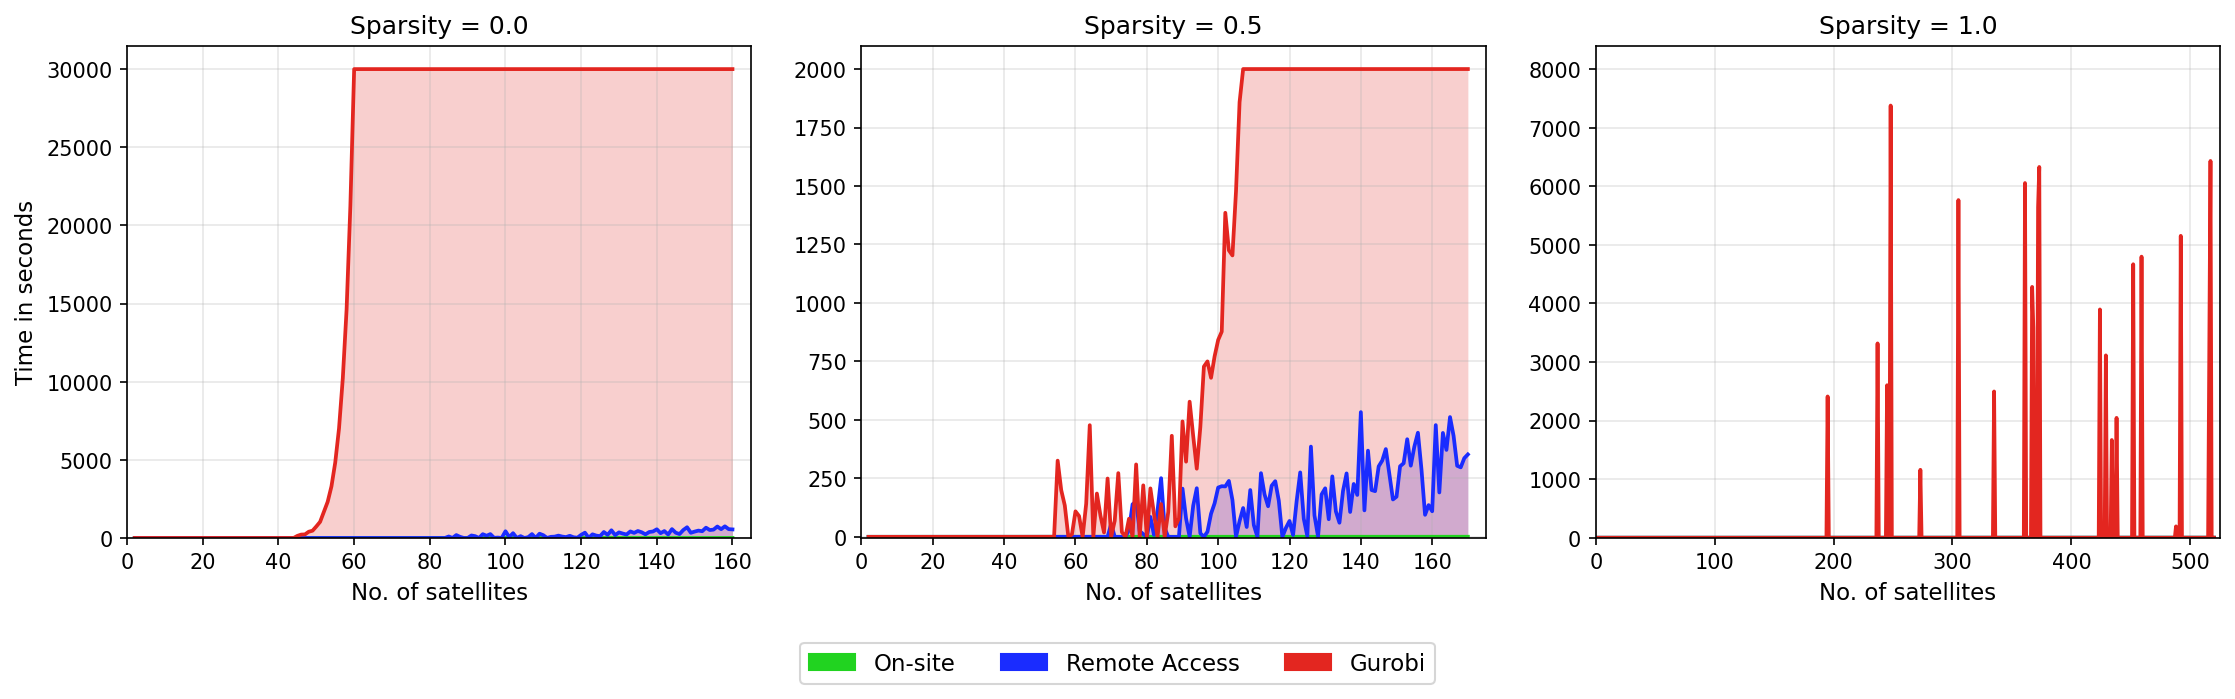

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Recreate the runtime comparison as 3 side-by-side sparsity panels.
rng = np.random.default_rng(7)

method_colors = {
    'On-site': '#21d320',
    'Remote Access': '#1a2cff',
    'Gurobi': '#e32620',
}

sparsity_levels = [0.0, 0.5, 1.0]
x_max = {0.0: 160, 0.5: 170, 1.0: 520}
y_max = {0.0: 30000, 0.5: 2000, 1.0: 8000}

runtime = {}
for s in sparsity_levels:
    n = np.arange(2, x_max[s] + 1)

    # On-site remains almost flat and close to zero for all sparsity levels.
    onsite = 0.18 + 0.002 * n + rng.normal(0, 0.015, n.size)
    onsite = np.clip(onsite, 0.03, None)

    if s == 0.0:
        remote = np.where(
            n < 85,
            0.12 + 0.003 * n + rng.normal(0, 0.04, n.size),
            40 + 0.23 * np.maximum(0, n - 85) ** 1.85 + rng.normal(0, 140, n.size),
        )
        remote = np.clip(remote, 0.02, 1200)

        gurobi = np.where(
            n < 45,
            0.15 + 0.004 * n + rng.normal(0, 0.02, n.size),
            120 * np.exp(0.37 * np.maximum(0, n - 45)) + rng.normal(0, 70, n.size),
        )
        gurobi = np.clip(gurobi, 0.02, y_max[s])

    elif s == 0.5:
        remote = np.where(
            n < 70,
            0.12 + 0.003 * n + rng.normal(0, 0.03, n.size),
            30 + 0.12 * np.maximum(0, n - 70) ** 1.7 + rng.normal(0, 120, n.size),
        )
        remote = np.clip(remote, 0.02, 1100)

        gurobi = np.where(
            n < 55,
            0.13 + 0.0035 * n + rng.normal(0, 0.03, n.size),
            18 + 3.8 * np.exp(0.12 * np.maximum(0, n - 55)) + rng.normal(0, 150, n.size),
        )
        gurobi = np.clip(gurobi, 0.02, y_max[s])

    else:
        remote = 0.10 + 0.0012 * np.maximum(0, n - 180) + rng.normal(0, 0.015, n.size)
        remote = np.clip(remote, 0.02, 600)

        gurobi = 0.08 + 0.0008 * np.maximum(0, n - 170) + rng.normal(0, 0.02, n.size)
        gurobi = np.clip(gurobi, 0.02, None)

        # Sparse case: occasional large spikes for Gurobi.
        spike_idx = rng.choice(np.where(n >= 180)[0], size=22, replace=False)
        gurobi[spike_idx] += rng.uniform(150, 7800, size=spike_idx.size)
        gurobi = np.clip(gurobi, 0.02, y_max[s])

    runtime[s] = {
        'n': n,
        'On-site': onsite,
        'Remote Access': remote,
        'Gurobi': gurobi,
    }

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), dpi=150)

for ax, s in zip(axes, sparsity_levels):
    n = runtime[s]['n']

    for method in ['On-site', 'Remote Access', 'Gurobi']:
        y = runtime[s][method]
        color = method_colors[method]
        ax.fill_between(n, 0, y, color=color, alpha=0.22, linewidth=0)
        ax.plot(n, y, color=color, linewidth=1.8)

    ax.set_title(f'Sparsity = {s:.1f}', fontsize=12)
    ax.set_xlabel('No. of satellites', fontsize=11)
    ax.set_xlim(0, x_max[s] + 5)
    ax.set_ylim(-5, y_max[s] * 1.05)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=10)

axes[0].set_ylabel('Time in seconds', fontsize=11)

legend_handles = [
    Patch(facecolor=method_colors['On-site'], edgecolor=method_colors['On-site'], label='On-site'),
    Patch(facecolor=method_colors['Remote Access'], edgecolor=method_colors['Remote Access'], label='Remote Access'),
    Patch(facecolor=method_colors['Gurobi'], edgecolor=method_colors['Gurobi'], label='Gurobi'),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=11,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()